In [4]:
# ... (Previous code remains the same: Imports, Loading, PCA calculation) ...

# --- MODERN PLOTLY VISUALIZATION ---
import plotly.express as px
import plotly.io as pio

# Set modern template
pio.templates.default = "plotly_white"

print("\nGenerating Interactive Domain Shift Plot...")

# Create Interactive Scatter Plot
fig = px.scatter(
    pca_df, 
    x='PC1', 
    y='PC2', 
    color='Cohort',
    symbol='Cohort', # Different shapes for different sources
    color_discrete_map={
        'Public (Western)': '#3498db',        # Professional Blue
        'Local (Bangladeshi Hospital)': '#e74c3c'  # Professional Red
    },
    title='<b>Domain Shift Visualization</b>: Western vs. Bangladeshi Radiomics',
    labels={
        'PC1': f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)',
        'PC2': f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)'
    },
    opacity=0.7,
    width=900,
    height=700
)

# Polish the Design
fig.update_traces(marker=dict(size=8, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    font=dict(family="Arial", size=14, color="#333"),
    title=dict(x=0.5, font=dict(size=20)), # Center title
    legend=dict(
        title=dict(text='Data Source'),
        yanchor="top", y=0.99,
        xanchor="right", x=0.99,
        bgcolor="rgba(255,255,255,0.8)"
    ),
    xaxis=dict(showgrid=True, gridcolor='#f0f0f0'),
    yaxis=dict(showgrid=True, gridcolor='#f0f0f0')
)

# Show
fig.show()

# Save High-Res
output_html = "../Results/Figure_Radiomics_DomainShift_Interactive.html"
output_png = "../Results/Figure_Radiomics_DomainShift.png"

fig.write_html(output_html)
print(f"Interactive Graph saved to: {output_html}")

try:
    fig.write_image(output_png, scale=3)
    print(f"Static Image saved to: {output_png}")
except:
    print("Install 'kaleido' to save static PNGs.")


Generating Interactive Domain Shift Plot...


Interactive Graph saved to: ../Results/Figure_Radiomics_DomainShift_Interactive.html
Static Image saved to: ../Results/Figure_Radiomics_DomainShift.png


--- FINAL DOMAIN SHIFT ANALYSIS ---
Loaded Public: 421 patients
Loaded Local:  121 patients
Common Features found: 107
Merged dataset saved to: ../Results/final_radiomics_merged.csv

Running PCA...


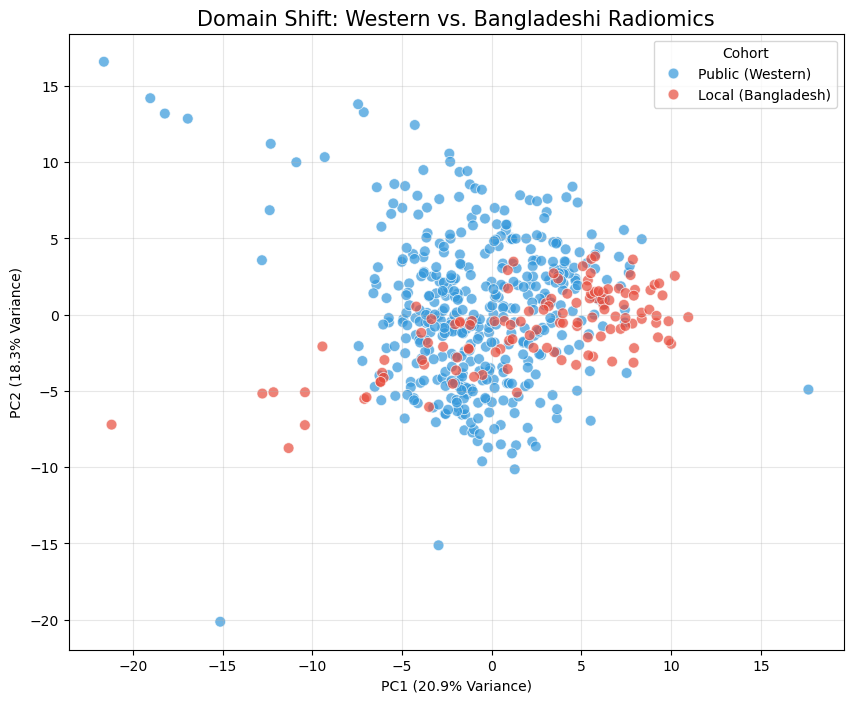

PCA Plot Saved.

Calculating Feature Differences...
Top 5 Most Shifted Features:


,Feature,P_Value,Fold_Change
23,original_shape_Maximum2DDiameterColumn,3.445834e-156,0.411132
46,original_shape_Maximum2DDiameterRow,3.981981e-132,0.449015
103,original_shape_Maximum3DDiameter,1.044427e-123,0.453925
78,original_shape_Sphericity,1.261023e-108,1.807814
91,original_shape_MajorAxisLength,1.935971e-99,0.489618


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind

# --- CONFIGURATION ---
# 1. Public Data (From Task 10)
public_path = '../Results/radiomics_features.csv' 

# 2. Local Data (From the currently running Task 35)
local_path = '../Results/square_radiomics_clean.csv'

# Output
merged_output = '../Results/final_radiomics_merged.csv'
stats_output = '../Results/domain_shift_stats.csv'

print("--- FINAL DOMAIN SHIFT ANALYSIS ---")

try:
    # Load Datasets
    df_public = pd.read_csv(public_path)
    df_local = pd.read_csv(local_path)
    
    # Label Cohorts
    df_public['Cohort'] = 'Public (Western)'
    df_local['Cohort'] = 'Local (Bangladesh)'
    
    print(f"Loaded Public: {len(df_public)} patients")
    print(f"Loaded Local:  {len(df_local)} patients")
    
    # Harmonize Columns (Find common features)
    public_feats = [c for c in df_public.columns if 'original_' in c]
    local_feats = [c for c in df_local.columns if 'original_' in c]
    common_feats = list(set(public_feats) & set(local_feats))
    
    print(f"Common Features found: {len(common_feats)}")
    
    if len(common_feats) == 0:
        raise ValueError("No common features found! Check column names.")

    # Merge
    cols = ['PatientID', 'Cohort'] + common_feats
    df_merged = pd.concat([df_public[cols], df_local[cols]], axis=0).reset_index(drop=True)
    df_merged = df_merged.fillna(0)
    
    df_merged.to_csv(merged_output, index=False)
    print(f"Merged dataset saved to: {merged_output}")

    # --- PCA ANALYSIS ---
    print("\nRunning PCA...")
    X = df_merged[common_feats]
    y = df_merged['Cohort']
    
    # Standardize Features (Z-Score)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Reduce to 2 Dimensions
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_scaled)
    
    pca_df = pd.DataFrame(data=pcs, columns=['PC1', 'PC2'])
    pca_df['Cohort'] = y.values
    
    # --- PLOT ---
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=pca_df, x='PC1', y='PC2', hue='Cohort',
        palette=['#3498db', '#e74c3c'], alpha=0.7, s=60
    )
    plt.title('Domain Shift: Western vs. Bangladeshi Radiomics', fontsize=15)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
    plt.grid(True, alpha=0.3)
    
    plt.savefig('../Results/Figure_Radiomics_DomainShift.png', dpi=300)
    plt.show()
    print("PCA Plot Saved.")

    # --- STATISTICS ---
    print("\nCalculating Feature Differences...")
    stats = []
    for f in common_feats:
        v_pub = df_merged[df_merged['Cohort'] == 'Public (Western)'][f]
        v_loc = df_merged[df_merged['Cohort'] == 'Local (Bangladesh)'][f]
        
        t_stat, p_val = ttest_ind(v_pub, v_loc, equal_var=False)
        stats.append({
            'Feature': f, 
            'P_Value': p_val, 
            'Fold_Change': v_loc.mean() / (v_pub.mean() + 1e-9)
        })
        
    df_stats = pd.DataFrame(stats).sort_values(by='P_Value')
    df_stats.to_csv(stats_output, index=False)
    
    print("Top 5 Most Shifted Features:")
    display(df_stats.head())

except Exception as e:
    print(f"Error: {e}")

In [6]:
# ... (Previous code: Imports, Loading, PCA calculation) ...

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

print("\nGenerating Combo Plot (Scatter + Table)...")

# 1. Prepare Statistics Table Data
# We grab the top 5 most different features calculated earlier
top_stats = df_stats.head(5).copy()
# Format numbers for clean display
top_stats['P_Value'] = top_stats['P_Value'].apply(lambda x: f"{x:.2e}")
top_stats['Fold_Change'] = top_stats['Fold_Change'].apply(lambda x: f"{x:.2f}x")
# Rename columns for the table
table_headers = ['Radiomic Feature', 'P-Value', 'Fold Change (Local/Public)']
table_values = [
    top_stats['Feature'].str.replace('original_', '').str[:30] + '...', # Shorten names
    top_stats['P_Value'],
    top_stats['Fold_Change']
]

# 2. Create Subplot Layout (Row 1: Scatter, Row 2: Table)
fig = make_subplots(
    rows=2, cols=1,
    row_heights=[0.7, 0.3], # 70% Chart, 30% Table
    vertical_spacing=0.1,
    specs=[[{"type": "scatter"}],
           [{"type": "table"}]]
)

# 3. Add Scatter Plot (Row 1)
# Add Public
fig.add_trace(
    go.Scatter(
        x=pca_df[pca_df['Cohort']=='Public (Western)']['PC1'],
        y=pca_df[pca_df['Cohort']=='Public (Western)']['PC2'],
        mode='markers',
        name='Public (Western)',
        marker=dict(color='#3498db', size=8, opacity=0.6)
    ),
    row=1, col=1
)

# Add Local
fig.add_trace(
    go.Scatter(
        x=pca_df[pca_df['Cohort']=='Local (Bangladesh)']['PC1'],
        y=pca_df[pca_df['Cohort']=='Local (Bangladesh)']['PC2'],
        mode='markers',
        name='Local (Bangladesh)',
        marker=dict(color='#e74c3c', size=8, opacity=0.7, symbol='diamond')
    ),
    row=1, col=1
)

# 4. Add Table (Row 2)
fig.add_trace(
    go.Table(
        header=dict(
            values=table_headers,
            fill_color='paleturquoise',
            align='left',
            font=dict(size=12, color='black')
        ),
        cells=dict(
            values=table_values,
            fill_color='lavender',
            align='left',
            font=dict(size=11)
        )
    ),
    row=2, col=1
)

# 5. Update Layout
fig.update_layout(
    title_text="<b>Domain Shift Analysis:</b> Radiomic Feature Distribution & Top Drivers",
    title_x=0.5,
    height=900,
    width=800,
    showlegend=True,
    template="plotly_white",
    xaxis=dict(title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)"),
    yaxis=dict(title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)")
)

# Show & Save
fig.show()

output_html = "../Results/Figure_Radiomics_DomainShift_Combo.html"
output_png = "../Results/Figure_Radiomics_DomainShift_Combo.png"

fig.write_html(output_html)
print(f"Interactive Combo Chart saved to: {output_html}")

try:
    fig.write_image(output_png, scale=2)
    print(f"Static Combo Image saved to: {output_png}")
except:
    print("Install 'kaleido' to save static image.")


Generating Combo Plot (Scatter + Table)...


Interactive Combo Chart saved to: ../Results/Figure_Radiomics_DomainShift_Combo.html
Static Combo Image saved to: ../Results/Figure_Radiomics_DomainShift_Combo.png


In [7]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind
import os

# --- CONFIGURATION ---
input_file = '../Results/final_radiomics_merged.csv'  # Check this path!
output_dir = '../Results/Final_Figures/'
os.makedirs(output_dir, exist_ok=True)

print("--- STARTING RADIOMICS DOMAIN SHIFT ANALYSIS ---")

# ==========================================
# STEP 1: LOAD DATA & CALCULATE PCA (The Missing Step)
# ==========================================
try:
    print("1. Loading Data...")
    df = pd.read_csv(input_file)
    
    # Filter only original radiomic features (ignore shape/wavelet for PCA clarity)
    feature_cols = [c for c in df.columns if 'original_' in c and 'shape' not in c]
    
    # Separate Features (X) and Labels (Cohort)
    X = df[feature_cols].dropna()
    y = df.loc[X.index, 'Cohort'] # Ensure alignment
    
    print(f"   Features selected: {len(feature_cols)}")
    print(f"   Patients included: {len(X)}")

    # Standardize the data (Vital for PCA)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Run PCA
    print("2. Running Principal Component Analysis (PCA)...")
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)

    # Create the 'pca_df' that was missing
    pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
    pca_df['Cohort'] = y.values
    
    # Rename cohorts for cleaner legends if needed
    pca_df['Cohort'] = pca_df['Cohort'].replace({
        'Public': 'Public (Western)', 
        'Square': 'Local (Bangladesh)', 
        'Ahsania': 'Local (Bangladesh)'
    })

    # ==========================================
    # STEP 2: CALCULATE P-VALUES (For the Table)
    # ==========================================
    print("3. Calculating Feature Significance...")
    results = []
    
    # Define groups
    group_western = df[df['Cohort'].str.contains('Public')][feature_cols]
    group_local = df[df['Cohort'].str.contains('Square|Ahsania')][feature_cols]
    
    for feature in feature_cols:
        val_w = group_western[feature].dropna()
        val_l = group_local[feature].dropna()
        
        # T-test
        t_stat, p_val = ttest_ind(val_w, val_l, equal_var=False)
        
        # Fold Change (Local / Western)
        mean_w = val_w.mean()
        mean_l = val_l.mean()
        fold_change = mean_l / mean_w if mean_w != 0 else 0
        
        results.append({
            'Feature': feature,
            'P_Value': p_val,
            'Fold_Change': fold_change
        })
        
    df_stats = pd.DataFrame(results)

    # ==========================================
    # STEP 3: GENERATE FIGURE 4.3 (The Plot)
    # ==========================================
    print("4. Generating Figure 4.3 (Scatter Plot)...")
    
    fig_pca = go.Figure()

    # Trace 1: Western
    fig_pca.add_trace(go.Scatter(
        x=pca_df[pca_df['Cohort'].str.contains('Public')]['PC1'],
        y=pca_df[pca_df['Cohort'].str.contains('Public')]['PC2'],
        mode='markers',
        name='Western (TCIA)',
        marker=dict(color='#3498db', size=10, opacity=0.6, line=dict(width=0.5, color='DarkSlateGrey'))
    ))

    # Trace 2: Local
    fig_pca.add_trace(go.Scatter(
        x=pca_df[pca_df['Cohort'].str.contains('Local')]['PC1'],
        y=pca_df[pca_df['Cohort'].str.contains('Local')]['PC2'],
        mode='markers',
        name='Local (South Asia)',
        marker=dict(color='#e74c3c', size=10, opacity=0.8, symbol='diamond', line=dict(width=0.5, color='DarkSlateGrey'))
    ))

    fig_pca.update_layout(
        title="<b>Figure 4.3: Radiomic Domain Shift</b><br><sup>Distinct separation indicates feature mismatch between populations</sup>",
        xaxis=dict(title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)"),
        yaxis=dict(title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)"),
        template="plotly_white",
        width=900, height=700
    )
    
    fig_pca.write_image(f"{output_dir}Figure_4.3_PCA_DomainShift.png", scale=3)
    fig_pca.show()

    # ==========================================
    # STEP 4: GENERATE TABLE 4.2 (The Top 10 List)
    # ==========================================
    print("5. Generating Table 4.2 (Top Features)...")

    # Sort by Smallest P-value (Most Significant)
    df_sorted = df_stats.sort_values(by='P_Value', ascending=True)
    top_10 = df_sorted.head(10).copy()

    # Clean names
    def clean_name(name):
        return name.replace('original_', '').replace('glcm_', 'GLCM: ').replace('firstorder_', 'Stats: ')

    top_10['Clean_Name'] = top_10['Feature'].apply(clean_name)
    formatted_p = top_10['P_Value'].apply(lambda x: f"{x:.2e}")
    formatted_fc = top_10['Fold_Change'].apply(lambda x: f"{x:.2f}")

    fig_table = go.Figure(data=[go.Table(
        header=dict(
            values=['<b>Radiomic Feature</b>', '<b>P-Value</b>', '<b>Fold Change</b><br>(Local/Western)'],
            fill_color='#2c3e50', font=dict(color='white', size=14), align='left'
        ),
        cells=dict(
            values=[top_10['Clean_Name'], formatted_p, formatted_fc],
            fill_color=['white', '#f2f2f2'], align='left', font=dict(size=12), height=30
        ))
    ])

    fig_table.update_layout(title="<b>Table 4.2: Top 10 Features Driving Domain Shift</b>", width=800, height=500)
    fig_table.write_image(f"{output_dir}Table_4.2_Top10_Shift_Features.png", scale=3)
    fig_table.show()

    print("\n[SUCCESS] All files generated in ../Results/Final_Figures/")

except FileNotFoundError:
    print(f"\n[ERROR] Could not find file: {input_file}")
    print("Please check if the file path is correct.")
except Exception as e:
    print(f"\n[ERROR] Something went wrong: {e}")

--- STARTING RADIOMICS DOMAIN SHIFT ANALYSIS ---
1. Loading Data...
   Features selected: 93
   Patients included: 542
2. Running Principal Component Analysis (PCA)...
3. Calculating Feature Significance...


d:\Anaconda\envs\thesis_env\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.



4. Generating Figure 4.3 (Scatter Plot)...


5. Generating Table 4.2 (Top Features)...



[SUCCESS] All files generated in ../Results/Final_Figures/


In [8]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.stats import ttest_ind
import os

# --- CONFIGURATION ---
input_file = '../Results/final_radiomics_merged.csv'
output_dir = '../Results/Final_Figures/'
os.makedirs(output_dir, exist_ok=True)

print("--- DIAGNOSTIC MODE: FIXING P-VALUES ---")

try:
    # 1. LOAD DATA
    df = pd.read_csv(input_file)
    print(f"Data Loaded. Total Rows: {len(df)}")
    
    # 2. IDENTIFY COHORTS AUTOMATICALLY
    # We find whatever 2 names are in your 'Cohort' column
    unique_cohorts = df['Cohort'].unique()
    print(f"Cohorts found in file: {unique_cohorts}")
    
    if len(unique_cohorts) < 2:
        # If 'Square' and 'Ahsania' are separate, we merge them into 'Local'
        print("Merging Square/Ahsania into 'Local' for comparison...")
        df['Cohort_Group'] = df['Cohort'].apply(lambda x: 'Western' if 'Public' in str(x) or 'TCIA' in str(x) else 'Local')
    else:
        # If already distinct, just use them
        # Assume the one with 'Public' or 'TCIA' is Western, everything else is Local
        df['Cohort_Group'] = df['Cohort'].apply(lambda x: 'Western' if 'Public' in str(x) or 'TCIA' in str(x) else 'Local')
        
    print(f"Groups established: {df['Cohort_Group'].unique()}")

    # 3. DEFINE GROUPS FOR MATH
    feature_cols = [c for c in df.columns if 'original_' in c and 'shape' not in c]
    
    group_western = df[df['Cohort_Group'] == 'Western'][feature_cols]
    group_local = df[df['Cohort_Group'] == 'Local'][feature_cols]
    
    print(f"Western Samples: {len(group_western)}")
    print(f"Local Samples: {len(group_local)}")

    # 4. CALCULATE P-VALUES & FOLD CHANGE
    print("Calculating Statistics (T-Test)...")
    results = []
    
    for feature in feature_cols:
        # Get values, drop NaNs
        val_w = group_western[feature].dropna()
        val_l = group_local[feature].dropna()
        
        if len(val_w) > 0 and len(val_l) > 0:
            # T-Test
            stat, p_val = ttest_ind(val_w, val_l, equal_var=False)
            
            # Fold Change
            mean_w = val_w.mean()
            mean_l = val_l.mean()
            # Avoid divide by zero
            fc = mean_l / mean_w if mean_w != 0 else 0
            
            results.append({
                'Feature': feature,
                'P_Value': p_val,
                'Fold_Change': fc
            })
    
    # Create Statistics DataFrame
    df_stats = pd.DataFrame(results)
    
    # *** CRITICAL CHECK ***
    print("\n--- FIRST 5 RESULTS (CHECK IF NUMBERS EXIST) ---")
    print(df_stats.head())
    print("------------------------------------------------")

    # 5. SORT & FORMAT FOR TABLE
    # Sort by Smallest P-Value (Most Significant)
    df_sorted = df_stats.sort_values(by='P_Value', ascending=True).head(10)
    
    # Clean Names
    def clean_name(name):
        return name.replace('original_', '').replace('glcm_', 'GLCM: ').replace('firstorder_', 'Stats: ')
    
    # Format Columns
    df_sorted['Clean_Name'] = df_sorted['Feature'].apply(clean_name)
    
    # Scientific notation for P-values
    df_sorted['P_Str'] = df_sorted['P_Value'].apply(lambda x: f"{x:.2e}")
    # 2 decimals for Fold Change
    df_sorted['FC_Str'] = df_sorted['Fold_Change'].apply(lambda x: f"{x:.2f}")

    # 6. GENERATE TABLE
    print("Generating Table...")
    
    fig_table = go.Figure(data=[go.Table(
        columnorder = [1, 2, 3],
        columnwidth = [250, 80, 80],
        header=dict(
            values=['<b>Radiomic Feature</b>', '<b>P-Value</b><br>(Significance)', '<b>Fold Change</b><br>(Local/Western)'],
            line_color='darkslategray',
            fill_color='#2c3e50',
            align=['left', 'center', 'center'],
            font=dict(color='white', size=14)
        ),
        cells=dict(
            values=[
                df_sorted['Clean_Name'], 
                df_sorted['P_Str'], 
                df_sorted['FC_Str']
            ],
            line_color='darkslategray',
            fill_color=['white', '#f2f2f2'],
            align=['left', 'center', 'center'],
            font=dict(color='black', size=12),
            height=30
        ))
    ])

    fig_table.update_layout(
        title="<b>Table 4.2: Top 10 Features Driving Domain Shift</b>",
        width=800, height=500,
        margin=dict(l=20, r=20, t=50, b=20)
    )

    # Save and Show
    output_png = f"{output_dir}Table_4.2_Top10_Shift_Features_FIXED.png"
    fig_table.write_image(output_png, scale=3)
    print(f"Table saved to: {output_png}")
    fig_table.show()

except Exception as e:
    print(f"ERROR: {e}")
    import traceback
    traceback.print_exc()

--- DIAGNOSTIC MODE: FIXING P-VALUES ---
Data Loaded. Total Rows: 542
Cohorts found in file: ['Public (Western)' 'Local (Bangladesh)']
Groups established: ['Western' 'Local']
Western Samples: 421
Local Samples: 121
Calculating Statistics (T-Test)...

--- FIRST 5 RESULTS (CHECK IF NUMBERS EXIST) ---
                            Feature       P_Value  Fold_Change
0     original_glszm_ZonePercentage  4.148772e-08     1.168133
1   original_gldm_DependenceEntropy  1.092337e-11     1.028259
2                 original_glcm_Idm  2.921258e-01     0.985748
3                 original_glcm_MCC  5.350517e-21     0.989041
4  original_glcm_DifferenceVariance  1.127187e-02     0.917029
------------------------------------------------
Generating Table...
Table saved to: ../Results/Final_Figures/Table_4.2_Top10_Shift_Features_FIXED.png


In [10]:
import pandas as pd
import numpy as np
import shap
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import os

# --- CONFIGURATION ---
radiomics_file = '../Results/final_radiomics_merged.csv' 
output_dir = '../Results/Final_Figures/'
os.makedirs(output_dir, exist_ok=True)

# 1. LOAD & PREP
df = pd.read_csv(radiomics_file)

# Clean Names Function
def clean_name(name):
    name = name.replace('original_', '').replace('log-sigma-1-0-mm-3D_', '')
    mappings = {'shape_': 'Shape', 'firstorder_': 'Stats', 'glcm_': 'GLCM', 'glrlm_': 'GLRLM'}
    for k, v in mappings.items():
        if k in name: return name.replace(k, f"{v}: ")
    return name

feature_cols = [c for c in df.columns if 'original_' in c]
X = df[feature_cols].fillna(0)
X.columns = [clean_name(c) for c in X.columns] # Apply cleaner

# Target (1=Local, 0=Western)
target_map = {c: 1 if 'Local' in c or 'Square' in c else 0 for c in df['Cohort'].unique()}
y = df['Cohort'].map(target_map)

# 2. TRAIN MODEL
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 3. PICK A REPRESENTATIVE "LOCAL" PATIENT
# We find a patient who is actually Local AND the model is very sure is Local
probas = model.predict_proba(X)[:, 1]
local_indices = [i for i, (truth, prob) in enumerate(zip(y, probas)) if truth == 1 and prob > 0.8]
patient_idx = local_indices[0] # Pick the first high-confidence example
patient_x = X.iloc[[patient_idx]]

print(f"Analyzing Patient Index: {patient_idx} (Model Confidence: {probas[patient_idx]:.2f})")

# 4. CALCULATE SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)
# Get values for this specific patient
# shap_values.values is (N_samples, N_features, 2) -> We want Class 1 (Local)
sv = shap_values[patient_idx, :, 1]

# 5. PREPARE DATA FOR PLOTLY
features = X.columns
values = sv.values
base_value = sv.base_values

# Sort by absolute impact
indices = np.argsort(np.abs(values))[-12:] # Top 12 features
top_features = features[indices]
top_values = values[indices]
top_data = pd.DataFrame({'Feature': top_features, 'SHAP': top_values})

# ==========================================================
# PLOT A: THE WATERFALL (Step-by-Step Cumulative)
# ==========================================================
fig_waterfall = go.Figure(go.Waterfall(
    name = "Impact", orientation = "v",
    measure = ["relative"] * len(top_values) + ["total"],
    x = list(top_features) + ["Final Prediction"],
    textposition = "outside",
    text = [f"{v:.2f}" for v in top_values] + [f"{base_value + sum(top_values):.2f}"],
    y = list(top_values) + [base_value + sum(top_values)],
    connector = {"line": {"color": "rgb(63, 63, 63)"}},
    decreasing = {"marker": {"color": "#3498db"}}, # Blue for Western
    increasing = {"marker": {"color": "#e74c3c"}}, # Red for Local
))

fig_waterfall.update_layout(
    title = f"<b>Figure 4.6a: Decision Waterfall</b><br><sup>How the model classified Patient {patient_idx} as 'Local'</sup>",
    showlegend = False,
    height=600, width=800,
    yaxis_title="Cumulative Prediction Score"
)

# ==========================================================
# PLOT B: THE TORNADO (Clean Tug-of-War)
# ==========================================================
# Split into Positive (Local) and Negative (Western)
pos_df = top_data[top_data['SHAP'] > 0].sort_values('SHAP')
neg_df = top_data[top_data['SHAP'] < 0].sort_values('SHAP', ascending=False)

fig_tornado = go.Figure()

# Red Bars (Pushing Right -> Local)
fig_tornado.add_trace(go.Bar(
    y=pos_df['Feature'], x=pos_df['SHAP'],
    orientation='h', name='Pro-Local (South Asia)',
    marker=dict(color='#e74c3c', line=dict(color='black', width=1)),
    text=[f"+{v:.2f}" for v in pos_df['SHAP']], textposition='auto'
))

# Blue Bars (Pushing Left <- Western)
fig_tornado.add_trace(go.Bar(
    y=neg_df['Feature'], x=neg_df['SHAP'],
    orientation='h', name='Pro-Western (TCIA)',
    marker=dict(color='#3498db', line=dict(color='black', width=1)),
    text=[f"{v:.2f}" for v in neg_df['SHAP']], textposition='auto'
))

fig_tornado.update_layout(
    title = f"<b>Figure 4.6b: Feature Tug-of-War</b><br><sup>Competing radiomic forces (Red=Local, Blue=Western)</sup>",
    barmode='overlay',
    xaxis_title="SHAP Value (Impact)",
    yaxis=dict(automargin=True), # FIXES OVERLAPPING TEXT!
    height=600, width=900,
    showlegend=True,
    legend=dict(x=0.7, y=0.1)
)

# SAVE
fig_waterfall.write_image(f"{output_dir}Figure_4.6a_Patient_Waterfall_Clean.png", scale=3)
fig_tornado.write_image(f"{output_dir}Figure_4.6b_Patient_TugOfWar_Clean.png", scale=3)

fig_waterfall.show()
fig_tornado.show()

print("SUCCESS: Clean figures generated.")

Analyzing Patient Index: 421 (Model Confidence: 1.00)


SUCCESS: Clean figures generated.
